# Jereme Carne Notebook
# Phase 5 - Dynon Data

- Author: [Jereme Carne]
- Repository: [datafun-04-notebooks](https://github.com/j-carne/datafun-04-notebooks/)
- Purpose: technical mod

## Dataset Information

- Dataset: Dynon Flight Data
- Description: Output file from my aircrafts flight instrument logging system
- Source: own
- Access: private

In [1]:
# This is a Python cell.


# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging  # for type hinting only
from typing import Any, Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes. Set title, labels, etc. on the axes.
# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("EDA-NB", level="DEBUG")
log_header(LOG, "EDA-NB")

# === Section 1c. Global Constants and Configuration ===

# CUSTOM: These are dataset-specific constants
# used in multiple places in the code.
# Inspect or explore the dataset to determine columns needed for analysis.

# CUSTOM: Data set name
DATASET_NAME: Final[str] = "dynon_flight_data"

# CUSTOM: Grouping column (chose one categorical/non-numeric variable)
GROUP_COL: Final[str] = "GPS Fix Quality"

# CUSTOM: Numeric columns to analyze (chose 4-5 numeric variables)
SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "CHT 1 (deg C)",
    "CHT 2 (deg C)",
    "CHT 3 (deg C)",
    "CHT 4 (deg C)",
    "Indicated Airspeed (knots)",
]

# === Section 1d. Pandas Configuration for Display ===

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-05 15:27:13 | INFO | EDA-NB | === RUN START ===
2026-06-05 15:27:13 | INFO | EDA-NB | project=EDA-NB
2026-06-05 15:27:13 | INFO | EDA-NB | repo_dir=datafun-04-notebooks
2026-06-05 15:27:13 | INFO | EDA-NB | python=3.14.5
2026-06-05 15:27:13 | INFO | EDA-NB | os=Windows 11
2026-06-05 15:27:13 | INFO | EDA-NB | shell=powershell
2026-06-05 15:27:13 | INFO | EDA-NB | cwd=notebooks
2026-06-05 15:27:13 | INFO | EDA-NB | github_actions=False
2026-06-05 15:27:13 | INFO | EDA-NB | Imports complete.


## Section 2. Load the Data

This is a Markdown cell.

WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

This is a Markdown cell.

In [2]:
# Python cell

# Load a dataset into a DataFrame.

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv("../data/raw/dynon_data.csv")
LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

2026-06-05 15:27:52 | INFO | EDA-NB | Loading dataset: dynon_flight_data
C:\Users\Jereme\AppData\Local\Temp\ipykernel_14508\1757074808.py:6: DtypeWarning: Columns (0: EGT Leaning State) have mixed types. Specify dtype option on import or set low_memory=False.
  df: pd.DataFrame = pd.read_csv("../data/raw/dynon_data.csv")
2026-06-05 15:27:52 | INFO | EDA-NB | Loaded: 14131 rows, 104 columns


## Section 3. Inspect Data Shape and Structure

WHY: Always start by understanding what columns exist,
what types they are, and how large the dataset is.

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).

This is a Markdown cell.

In [3]:
# Section 3 Python cell

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-05 15:28:24 | INFO | EDA-NB | Previewing first few rows of the dataset


,Session Time,GPS Fix Quality,Number of Satellites,GPS Date & Time,Latitude (deg),Longitude (deg),GPS Altitude (feet),Ground Speed (knots),Ground Track (deg),Mag Var (deg),Cross Track Error (NM),Destination Waypoint ID,Range to Destination (NM),Bearing to Destination (deg),System Time,Pitch (deg),Roll (deg),Magnetic Heading (deg),Indicated Airspeed (knots),Pressure Altitude (ft),Turn Rate (deg/s),Lateral Accel (g),Vertical Accel(g),Angle of Attack (%),Vertical Speed (ft/min),...,CHT 3 (deg C),EGT 3 (deg C),CHT 2 (deg C),EGT 2 (deg C),CHT 1 (deg C),EGT 1 (deg C),Thermocouple 13 (deg C),Thermocouple 14 (deg C),ELEV POSITION (%),FLAPS POSITION (deg),GP Input 3,FUEL PRESSURE (PSI),PHEAT CONTACT (V),AILERN POSITION (%),EARTHX CONTACT (V),GP Input 8,LEFT LEVEL (gal),RIGHT LEVEL (gal),OIL PRESSURE (PSI),OIL TEMPERATURE (deg C),GP Input 13,Contacts,Percent Power,EGT Leaning State,Unnamed: 103
0,37.69,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,23:57:43,2.2,-0.3,156.1,0.0,4175.0,0.1,-0.01,1.0,99.0,0.0,...,13.0,13.0,13.0,13.0,13.0,13.0,NaN,NaN,-3.0,27.0,NaN,0.0,0.0,12.0,4.998,NaN,6.7,9.4,0.4,12.5,NaN,NaN,NaN,NaN,NaN
1,38.19,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,23:57:44,2.2,-0.3,156.1,0.0,4175.0,0.0,-0.01,1.0,99.0,5.0,...,13.0,13.0,13.0,13.0,13.0,13.0,NaN,NaN,-3.0,27.0,NaN,0.0,0.0,12.0,4.998,NaN,6.7,9.4,0.5,12.5,NaN,NaN,NaN,NaN,NaN
2,38.69,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,23:57:44,2.1,-0.3,156.1,0.0,4175.0,0.0,-0.01,1.0,99.0,20.0,...,13.0,13.0,13.0,13.0,13.0,13.0,NaN,NaN,-3.0,27.0,NaN,0.0,0.0,12.0,4.998,NaN,6.7,9.4,0.5,12.5,NaN,NaN,NaN,NaN,NaN
3,39.19,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,23:57:45,2.1,-0.3,156.0,0.0,4175.0,0.0,-0.01,1.0,99.0,14.0,...,13.0,13.0,13.0,13.0,13.0,13.0,NaN,NaN,-3.0,27.0,NaN,0.0,0.0,12.0,4.998,NaN,6.7,9.4,0.5,12.6,NaN,NaN,NaN,NaN,NaN
4,39.69,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,23:57:45,2.1,-0.4,156.0,0.0,4175.0,0.0,-0.01,1.0,99.0,1.0,...,13.0,13.0,13.0,13.0,13.0,13.0,NaN,NaN,-3.0,27.0,NaN,0.0,0.0,12.0,4.998,NaN,6.7,9.4,0.5,12.5,NaN,NaN,NaN,NaN,NaN


In [4]:
# Section 3 Python cell

LOG.info("Column names")
print(list(df.columns))

2026-06-05 15:28:36 | INFO | EDA-NB | Column names


['Session Time', 'GPS Fix Quality', 'Number of Satellites', 'GPS Date & Time', 'Latitude (deg)', 'Longitude (deg)', 'GPS Altitude (feet)', 'Ground Speed (knots)', 'Ground Track (deg)', 'Mag Var (deg)', 'Cross Track Error (NM)', 'Destination Waypoint ID', 'Range to Destination (NM)', 'Bearing to Destination (deg)', 'System Time', 'Pitch (deg)', 'Roll (deg)', 'Magnetic Heading (deg)', 'Indicated Airspeed (knots)', 'Pressure Altitude (ft)', 'Turn Rate (deg/s)', 'Lateral Accel (g)', 'Vertical Accel(g)', 'Angle of Attack (%)', 'Vertical Speed (ft/min)', 'OAT (deg C)', 'True Airspeed (knots)', 'Barometer Setting (inHg)', 'Density Altitude (ft)', 'Wind Direction (deg)', 'Wind Speed (knots)', 'Heading Bug (deg)', 'Altitude Bug (ft)', 'Airspeed Bug (knots)', 'Vertical Speed Bug (ft/min)', 'Course (deg)', 'CDI Source Type', 'CDI Source Port', 'CDI Scale (NM)', 'CDI Deflection (%)', 'Glideslope (%)', 'AP Engaged', 'AP Roll Mode', 'AP Roll Force', 'AP Roll Position (steps)', 'AP Roll Slip (bool)',

In [5]:
# Section 3 Python cell

# DataFrame info (types and non-null counts)
# WHY: df.info() prints directly - no display() needed.
LOG.info("DataFrame info (types and non-null counts)")
df.info()

2026-06-05 15:28:40 | INFO | EDA-NB | DataFrame info (types and non-null counts)


<class 'pandas.DataFrame'>
RangeIndex: 14131 entries, 0 to 14130
Columns: 104 entries, Session Time to Unnamed: 103
dtypes: float64(101), str(3)
memory usage: 11.2 MB


In [6]:
# Section 3 Python cell

# Get shape - number of rows and columns
# It has two parts so the return value is a tuple of (num_rows, num_columns)
shape: tuple[int, int] = df.shape

# To get each value, we can unpack the tuple into two variables
# This is a common Python idiom for working with tuples.
# Or we could just use shape[0] and shape[1] directly without unpacking.

num_rows, num_cols = shape

LOG.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")

2026-06-05 15:28:43 | INFO | EDA-NB | Dataset shape: 14131 rows, 104 columns


## Section 4. Create Data Dictionary and Check Data Quality

WHY: A data dictionary helps with understanding the structure and quality of the data.

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)

This is a Markdown cell.


In [7]:
# Section 4 Python cell

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-05 15:29:36 | INFO | EDA-NB | Building starter data dictionary
2026-06-05 15:29:36 | DEBUG | EDA-NB | 
                   column    dtype  missing_count  missing_pct
0            Session Time  float64              0         0.00
1         GPS Fix Quality  float64              4         0.03
2    Number of Satellites  float64              4         0.03
3         GPS Date & Time      str            259         1.83
4          Latitude (deg)  float64            260         1.84
..                    ...      ...            ...          ...
99            GP Input 13  float64          14131       100.00
100              Contacts  float64          14131       100.00
101         Percent Power  float64          14126        99.96
102     EGT Leaning State      str          14126        99.96
103          Unnamed: 103  float64          14131       100.00

[104 rows x 4 columns]


In [8]:
# Section 4 Python cell

LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df[SELECTED_NUMERIC_COLS].describe()}\n")

2026-06-05 15:30:37 | INFO | EDA-NB | Missing values per column:
2026-06-05 15:30:37 | INFO | EDA-NB | Session Time                0
GPS Fix Quality             4
Number of Satellites        4
GPS Date & Time           259
Latitude (deg)            260
                        ...  
GP Input 13             14131
Contacts                14131
Percent Power           14126
EGT Leaning State       14126
Unnamed: 103            14131
Length: 104, dtype: int64
2026-06-05 15:30:37 | INFO | EDA-NB | Checking missing values per column
2026-06-05 15:30:37 | DEBUG | EDA-NB | 
Range to Destination (NM)       14131
Bearing to Destination (deg)    14131
Cross Track Error (NM)          14131
Destination Waypoint ID         14131
Fuel Flow 2 (gal/hr)            14131
                                ...  
Tach Time                           4
Heading Bug (deg)                   3
Mag Var (deg)                       2
System Time                         2
Session Time                        0
Length: 10

## Section 5. Create Clean View for EDA

Create a cleaned view for EDA.

Strategy:
  - Keep the original DataFrame unchanged
  - Drop rows missing key numeric fields and grouping field

WHY: EDA often focuses on a "clean" subset of the data.

This allows exploring patterns without being distracted by missing values.

This is a Markdown cell.

In [9]:
# Section 5 Python cell

# Build the list of columns we require to be non-missing
# This includes all the selected numeric columns plus the grouping column.
# SELECTED_NUMERIC_COLS is a list of strings,
# GROUP_COL is a single string
# Wrap GROUP_COL in a list - two lists can be combined with +
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

# Drop a row if it is missing a value in ANY of the required columns
# dropna(subset=...) only looks at the specified columns, not the whole row
# .copy() creates a new DataFrame so we don't accidentally modify the original
df_clean: pd.DataFrame = df.dropna(subset=cols_required).copy()

# Compare sizes
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-05 15:31:18 | DEBUG | EDA-NB | Columns required to be non-missing: ['CHT 1 (deg C)', 'CHT 2 (deg C)', 'CHT 3 (deg C)', 'CHT 4 (deg C)', 'Indicated Airspeed (knots)', 'GPS Fix Quality']
2026-06-05 15:31:18 | INFO | EDA-NB | Original rows: 14131
2026-06-05 15:31:18 | INFO | EDA-NB | Clean rows:    14122
2026-06-05 15:31:18 | INFO | EDA-NB | Rows dropped:  9


Original rows: 14131
Clean rows:    14122
Rows dropped:  9


## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics offer a quick overview of numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

Grouping by a categorical variable (i.e., non-numeric column)
enables comparing statistics across categories

This is a Markdown cell.

In [11]:
# Section 6 Python cell

LOG.info("--------------- Manual statistics ---------------")

mean_cht1 = np.mean(df_clean["CHT 1 (deg C)"])
std_cht1 = np.std(df_clean["CHT 1 (deg C)"])
min_cht1 = np.min(df_clean["CHT 1 (deg C)"])
max_cht1 = np.max(df_clean["CHT 1 (deg C)"])
range_cht1 = np.max(df_clean["CHT 1 (deg C)"]) - np.min(df_clean["CHT 1 (deg C)"])

LOG.info("CHT 1 Statistics (using numpy):")
LOG.info(f"  Mean: {mean_cht1:.2f} deg C")
LOG.info(f"  Std Dev: {std_cht1:.2f} deg C")
LOG.info(f"  Min: {min_cht1:.2f} deg C")
LOG.info(f"  Max: {max_cht1:.2f} deg C")
LOG.info(f"  Range: {range_cht1:.2f} deg C")

2026-06-05 15:32:51 | INFO | EDA-NB | --------------- Manual statistics ---------------
2026-06-05 15:32:51 | INFO | EDA-NB | CHT 1 Statistics (using numpy):
2026-06-05 15:32:51 | INFO | EDA-NB |   Mean: 144.40 deg C
2026-06-05 15:32:51 | INFO | EDA-NB |   Std Dev: 37.08 deg C
2026-06-05 15:32:51 | INFO | EDA-NB |   Min: 13.00 deg C
2026-06-05 15:32:51 | INFO | EDA-NB |   Max: 182.00 deg C
2026-06-05 15:32:51 | INFO | EDA-NB |   Range: 169.00 deg C


In [12]:
# Section 6 Python cell

# LOG.info("--------------- Using pandas describe() method ---------------")

LOG.info("Computing overall descriptive statistics")

# Use describe() to get count, mean, std, min, 25%, 50%, 75%, max for numeric columns
# OPTION: Use .T to transpose the result so that columns become rows for easier reading in logs
stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

# Step 1: Select only the numeric columns we want to summarize
df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Split the numeric subset into groups based on the grouping column
# groupby() returns a GroupBy object - not a DataFrame yet, just a plan to group
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: For each group, compute multiple summary statistics at once
# agg() applies each function in the list to each numeric column
# The result has a multi-level column index: (numeric_column, statistic)
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

2026-06-05 15:33:08 | INFO | EDA-NB | Computing overall descriptive statistics
2026-06-05 15:33:08 | DEBUG | EDA-NB | 
                              count        mean        std   min      25%    50%    75%    max
CHT 1 (deg C)               14122.0  144.397536  37.078070  13.0  133.000  151.0  173.0  182.0
CHT 2 (deg C)               14122.0  142.685809  37.579192  13.0  131.000  151.0  171.0  181.0
CHT 3 (deg C)               14122.0  146.236440  34.166399  13.0  142.000  155.0  168.0  177.0
CHT 4 (deg C)               14122.0  144.558561  34.247759  13.0  142.000  154.0  166.0  175.0
Indicated Airspeed (knots)  14122.0   86.134485  51.852655   0.0   37.775   94.0  133.1  165.8
2026-06-05 15:33:08 | INFO | EDA-NB | --------------- Using pandas groupby() and agg() ---------------
2026-06-05 15:33:08 | INFO | EDA-NB | Computing descriptive statistics by group
2026-06-05 15:33:08 | DEBUG | EDA-NB | 
                CHT 1 (deg C)                                     CHT 2 (deg C)         

In [13]:
# Section 6 Python cell

LOG.info("--------------- Improving the output ---------------")

# Yuck: That's the multi-level column index in action.
# pandas lays out the result as (numeric_column, statistic) pairs
# side by side, wrapping when the terminal width runs out.
# With 4 numeric columns x 5 statistics = 20 columns total,
# it can only fit 2 numeric columns per line at 120 characters wide.
# Let's stack it so each numeric column's stats are grouped together
# vertically instead of horizontally.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-05 15:33:22 | INFO | EDA-NB | --------------- Improving the output ---------------
2026-06-05 15:33:22 | DEBUG | EDA-NB | 
                                            count        mean        std   min    max
GPS Fix Quality                                                                      
0.0             CHT 1 (deg C)                 252   59.603175  47.668941  13.0  111.0
                CHT 2 (deg C)                 252   59.146825  47.189858  13.0  110.0
                CHT 3 (deg C)                 252   66.706349  54.940325  13.0  126.0
                CHT 4 (deg C)                 252   65.642857  53.982432  13.0  124.0
                Indicated Airspeed (knots)    252    0.000000   0.000000   0.0    0.0
1.0             CHT 1 (deg C)                3900  135.915128  50.607935  13.0  182.0
                CHT 2 (deg C)                3900  134.606410  51.393006  13.0  181.0
                CHT 3 (deg C)                3900  137.855128  48.529437  13.0  177.0
         

## Section 7. Simple Correlations (Numeric Only)

Compute a simple numeric correlations to understand
relationships between numeric variables.

A correlation matrix is symmetric.
There are as many columns as numeric variables.
There are as many rows as numeric variables.
The diagonal values are always exactly 1.0.
since each variable perfectly correlates with itself.

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship

This is a Markdown cell.

In [16]:
# Section 7 Python cell

LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns
df_clean_numeric_cols: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]
correlation_matrix = df_clean_numeric_cols.corr()

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-05 15:35:57 | INFO | EDA-NB | Computing correlation matrix for numeric columns
2026-06-05 15:35:57 | INFO | EDA-NB | 
Correlation matrix:
2026-06-05 15:35:57 | DEBUG | EDA-NB | 
                            CHT 1 (deg C)  CHT 2 (deg C)  CHT 3 (deg C)  CHT 4 (deg C)  Indicated Airspeed (knots)
CHT 1 (deg C)                    1.000000       0.996866       0.982403       0.982049                    0.800598
CHT 2 (deg C)                    0.996866       1.000000       0.977563       0.980461                    0.821014
CHT 3 (deg C)                    0.982403       0.977563       1.000000       0.997949                    0.701988
CHT 4 (deg C)                    0.982049       0.980461       0.997949       1.000000                    0.715836
Indicated Airspeed (knots)       0.800598       0.821014       0.701988       0.715836                    1.000000


2026-06-05 15:35:59 | INFO | EDA-NB | ---------Visualize Correlation Matrix as a Heatmap---------------


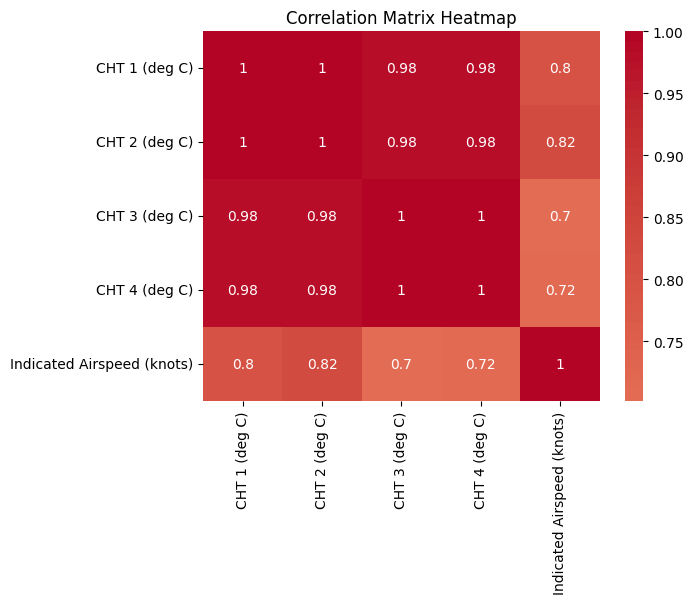

In [17]:
# Section 7 Python cell

LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

# Set annotations to True to show correlation values
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",  # try coolwarm, viridis, plasma, or other colormaps
    center=0,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

CUSTOM: Update these notes and use Markdown cells to narrate and tell the story as you explore. For example:

Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that **flipper_length_mm** and **body_mass_g** show strong positive correlation (~0.87).

This is a Markdown cell.

## Section 8. Make Plots

Create simple, notebook-friendly plots.

WHY: Visualizations reveal patterns not obvious in tables.
CUSTOM: Charts will vary depending on the dataset
        and questions of interest.

Common charts include:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

A scatter plot shows the relationship between two numeric variables.
In this example:
- Each dot is one data record shown as x vs y.
- Color (hue) provides a third dimension.

A box plot shows the distribution of one numeric variable across groups.
- The box shows the middle 50% of values.
- The line inside the box is the median.
- The whiskers show the range. Dots beyond the whiskers are outliers.


This is a Markdown cell.

2026-06-05 15:37:58 | INFO | EDA-NB | ---- Creating Scatter Plot to see Relationships ------
2026-06-05 15:37:58 | INFO | EDA-NB | ----   Use clean dataframe ---------------------------
2026-06-05 15:37:58 | INFO | EDA-NB | ----   Set x to flipper length -----------------------
2026-06-05 15:37:58 | INFO | EDA-NB | ----   Set y to bill length --------------------------
2026-06-05 15:37:58 | INFO | EDA-NB | ----   Set the hue (color mapping) to the group column --


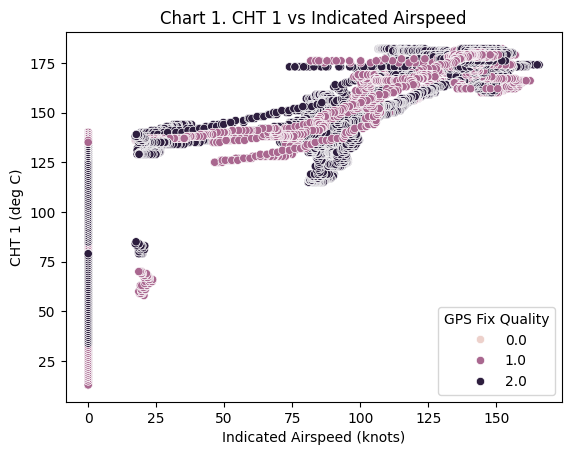

In [18]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info("----   Set x to flipper length -----------------------")
LOG.info("----   Set y to bill length --------------------------")
LOG.info("----   Set the hue (color mapping) to the group column --")

# Scatter plot to see relationship
scatter_plt: Axes = sns.scatterplot(
    data=df_clean,
    x="Indicated Airspeed (knots)",
    y="CHT 1 (deg C)",
    hue=GROUP_COL,
)
scatter_plt.set_xlabel("Indicated Airspeed (knots)")
scatter_plt.set_ylabel("CHT 1 (deg C)")
scatter_plt.set_title("Chart 1. CHT 1 vs Indicated Airspeed")

# IN NOTEBOOK: SHOW AS YOU GO
#      plt.show() displays the current chart and closes it
#      Call this before starting a new chart
#      or next chart will be drawn on top of this one
# IN SCRIPT: WAIT TO SHOW TILL THE END
#      Do not call plt.show() here - let figures accumulate
#      so all charts display together with sequential Figure numbers.
#      plt.show() is called once at the end of make_plots()
plt.show()

2026-06-05 15:40:55 | INFO | EDA-NB | ------- Creating another chart -------
2026-06-05 15:40:55 | INFO | EDA-NB | ------ Creating Box Plot to see Distribution: ---------
2026-06-05 15:40:55 | INFO | EDA-NB | ------   Use clean dataframe --------------------------
2026-06-05 15:40:55 | INFO | EDA-NB | ------   Set x to GPS Fix Quality ---------------------
2026-06-05 15:40:55 | INFO | EDA-NB | ------   Set y to CHT 1 (deg C) ----------------------


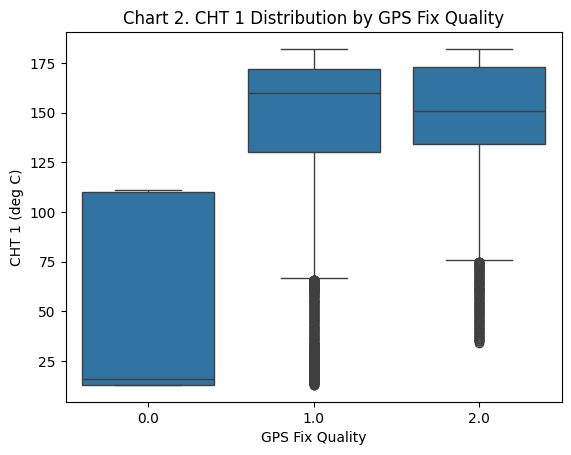

In [22]:
LOG.info("------- Creating another chart -------")
# plt.figure() opens a fresh blank canvas for the next chart
# WHY: Without this, Chart 2 draws on top of Chart 1
plt.figure()

LOG.info("------ Creating Box Plot to see Distribution: ---------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to GPS Fix Quality ---------------------")
LOG.info("------   Set y to CHT 1 (deg C) ----------------------")

# Box plot to compare distribution across species
box_plt: Axes = sns.boxplot(
    data=df_clean,
    x=GROUP_COL,
    y="CHT 1 (deg C)",
)
box_plt.set_xlabel("GPS Fix Quality")
box_plt.set_ylabel("CHT 1 (deg C)")
box_plt.set_title("Chart 2. CHT 1 Distribution by GPS Fix Quality")

plt.show()

## Section 9. Summary and Next Steps

At the end, of your notebook, provide:

-  brief summary of your findings 
-  suggested next steps

WHY: EDA is not a final report.
The summary of your data exploration captures you found 
and what you would like to investigate next.

This summary is in code because it is instructional - your summary
will typically be in Markdown as it is good for narrative. 

This is a Markdown cell.


In [23]:
# Section 9 Python cell

LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Get the unique values in the grouping column
unique_groups_array: np.ndarray = df_clean[GROUP_COL].unique()

# Sort them so the output is consistent and readable
sorted_groups: list[str] = sorted(unique_groups_array)

LOG.info(f"Groups found in {GROUP_COL}: {sorted_groups}")

LOG.info("Strongest correlations: ")
LOG.info("  CHT 1 and CHT 2 (~1.0) - all cylinders heat and cool together")
LOG.info("  CHT 1 and Indicated Airspeed (~0.80) - higher airspeed = higher CHT")
LOG.info("  CHT 2 and Indicated Airspeed (~0.82) - slightly stronger than CHT 1")
LOG.info("  CHT 3 and CHT 4 show slightly weaker airspeed correlation (~0.70-0.72)")

LOG.info("Suggested next step: ")
LOG.info("  Model CHT ~ Indicated Airspeed with linear regression")
LOG.info(
    "  Investigate why front cylinders (1,2) correlate more strongly with airspeed"
)

LOG.info("EDA workflow complete")
LOG.info("IMPORTANT: This script creates chart windows.")
LOG.info("Close any chart windows and terminate this process with CTRL+c as needed.")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-05 15:42:09 | INFO | EDA-NB | ========================
2026-06-05 15:42:09 | INFO | EDA-NB | SUMMARY
2026-06-05 15:42:09 | INFO | EDA-NB | ========================
2026-06-05 15:42:09 | INFO | EDA-NB | Dataset: dynon_flight_data
2026-06-05 15:42:09 | INFO | EDA-NB | Original rows: 14131
2026-06-05 15:42:09 | INFO | EDA-NB | Clean rows:    14122
2026-06-05 15:42:09 | INFO | EDA-NB | Groups found in GPS Fix Quality: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
2026-06-05 15:42:09 | INFO | EDA-NB | Strongest correlations: 
2026-06-05 15:42:09 | INFO | EDA-NB |   CHT 1 and CHT 2 (~1.0) - all cylinders heat and cool together
2026-06-05 15:42:09 | INFO | EDA-NB |   CHT 1 and Indicated Airspeed (~0.80) - higher airspeed = higher CHT
2026-06-05 15:42:09 | INFO | EDA-NB |   CHT 2 and Indicated Airspeed (~0.82) - slightly stronger than CHT 1
2026-06-05 15:42:09 | INFO | EDA-NB |   CHT 3 and CHT 4 show slightly weaker airspeed correlation (~0.70-0.72)
2026-06-05 15:42:09 | INFO | E

## Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

This is a Markdown cell.


2026-06-05 15:42:45 | INFO | EDA-NB | ------- Creating Histogram -------
2026-06-05 15:42:45 | INFO | EDA-NB | ------ Showing distribution of CHT 1 by GPS Fix Quality ------


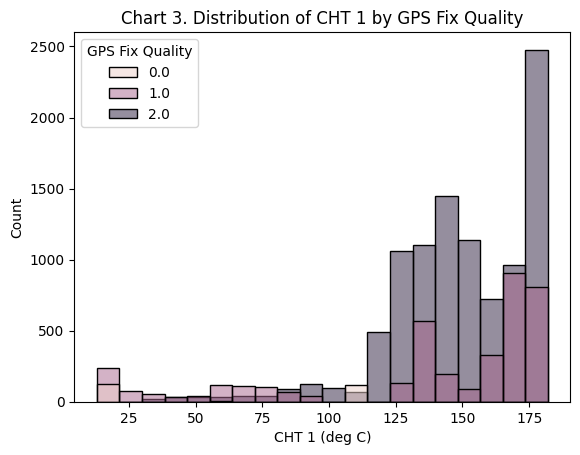

In [24]:
LOG.info("------- Creating Histogram -------")
plt.figure()

LOG.info("------ Showing distribution of CHT 1 by GPS Fix Quality ------")

hist_plt: Axes = sns.histplot(
    data=df_clean,
    x="CHT 1 (deg C)",
    hue=GROUP_COL,
    bins=20,
)
hist_plt.set_xlabel("CHT 1 (deg C)")
hist_plt.set_ylabel("Count")
hist_plt.set_title("Chart 3. Distribution of CHT 1 by GPS Fix Quality")

plt.show()